In [1]:
import logging
from tmu.models.classification.vanilla_classifier import TMClassifier
import os
import config
import pickle
import numpy as np
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_otsu_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 20:44:12,718 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 20:44:12,725 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 20:44:12,739 - matplotlib - DEBUG - interactive is False
2026-05-10 20:44:12,740 - matplotlib - DEBUG - platform is linux
2026-05-10 20:44:12,797 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 20:44:12,799 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.OTSU
CURRENT_DATASET = config.BREASTMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Otsu"]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_otsu_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)
Y_val = Y_val.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=0)

[I 2026-03-21 20:38:34,131] A new study created in memory with name: no-name-d026cac9-08ab-4286-8c0c-eab60e4d8af0


[I 2026-03-21 20:49:16,108] Trial 0 finished with value: 0.7657657657657657 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7657657657657657.


[I 2026-03-21 21:00:35,477] Trial 1 finished with value: 0.6756756756756757 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7657657657657657.


[I 2026-03-21 21:12:35,762] Trial 2 finished with value: 0.8018867924528302 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.8018867924528302.


[I 2026-03-21 21:23:38,716] Trial 3 finished with value: 0.7476635514018691 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 2 with value: 0.8018867924528302.


...

[I 2026-03-22 05:41:49,205] Trial 46 finished with value: 0.72 and parameters: {'s': 13.0, 'T': 1000, 'patch_size': 3, 'max_included_literals': 32}. Best is trial 44 with value: 0.8571428571428571.


[I 2026-03-22 06:00:43,821] Trial 47 finished with value: 0.7798165137614679 and parameters: {'s': 14.0, 'T': 4000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 44 with value: 0.8571428571428571.


[I 2026-03-22 06:18:54,160] Trial 48 finished with value: 0.7211538461538461 and parameters: {'s': 3.0, 'T': 2500, 'patch_size': 9, 'max_included_literals': 32}. Best is trial 44 with value: 0.8571428571428571.


[I 2026-03-22 06:35:47,098] Trial 49 finished with value: 0.8108108108108109 and parameters: {'s': 10.0, 'T': 6000, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 44 with value: 0.8571428571428571.


Best fbeta: 0.8571428571428571
Best hyperparameters: {'s': 12.0, 'T': 1500, 'patch_size': 9, 'max_included_literals': 128}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/otsu.json")

Best F1 score macro accuracy: 0.8571428571428571
Best hyperparameters: {'s': 12.0, 'T': 1500, 'patch_size': 9, 'max_included_literals': 128}
Best Optuna results saved to hyperparameters/otsu.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/otsu.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Otsu",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 80.13% (12.83s)


#2 Accuracy: 79.49% (13.13s)


#3 Accuracy: 82.05% (12.66s)


#4 Accuracy: 69.87% (12.41s)


...

#96 Accuracy: 82.69% (8.55s)


#97 Accuracy: 84.62% (8.66s)


#98 Accuracy: 83.97% (8.55s)


#99 Accuracy: 83.33% (8.54s)


#100 Accuracy: 83.97% (8.54s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Otsu_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

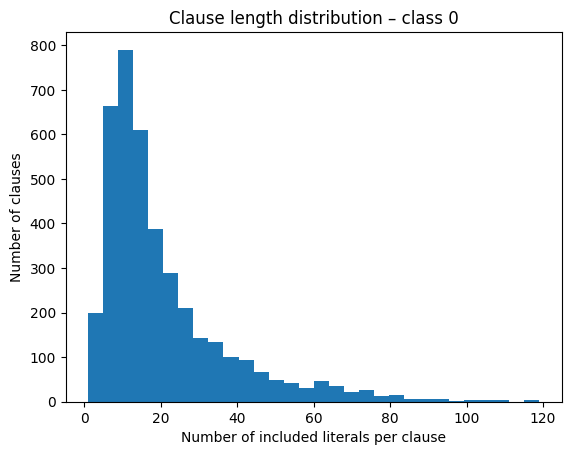

Class 0: median=15.0, mean=20.5, std=17.1


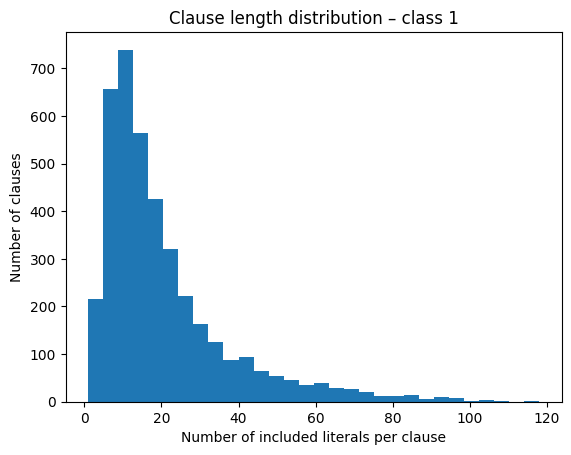

Class 1: median=15.0, mean=20.5, std=17.1


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 83.97%
2026-05-10 20:44:32,113 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:44:32,115 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:44:32,139 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x78dcb7ae5580>
Saved to saved_confusion_matrices/breast_otsu.svg


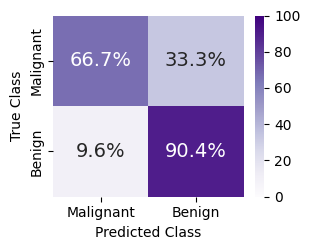

In [9]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BreastMNIST_Otsu", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "Purples") 

# Class 0 Local Examples  

In [18]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 11
True class: 0
Predicted class: 0
Selected image index: 123
True class: 0
Predicted class: 0
Selected image index: 26
True class: 0
Predicted class: 0


0
2026-04-10 15:22:16,825 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:22:16,830 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 11  |  predicted class: 0
2026-04-10 15:22:16,862 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740cf10350>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s11_aggr.svg


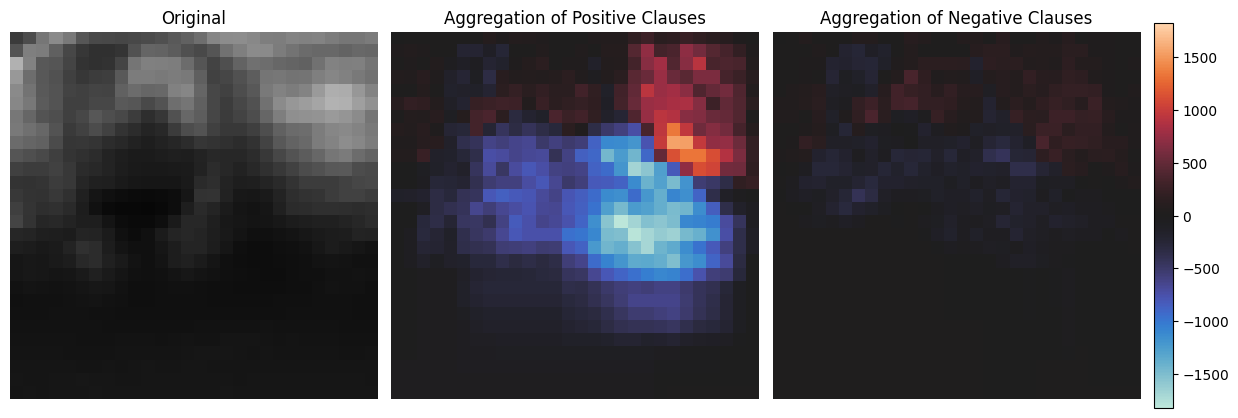

Visualizing sample 11  |  predicted class: 0
2026-04-10 15:22:20,404 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740bc5f230>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s11_chan.svg


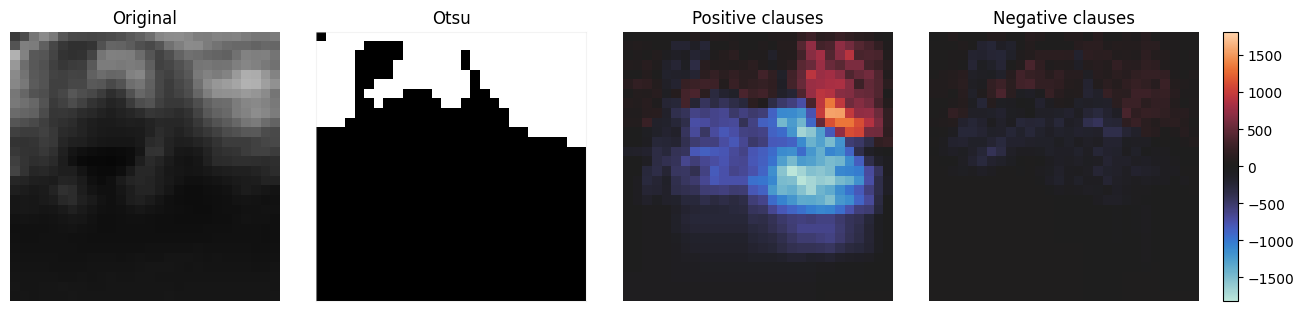

In [9]:
image_index =  11
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 123  |  predicted class: 0
2026-04-10 15:22:23,998 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740bb58a40>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s123_aggr.svg


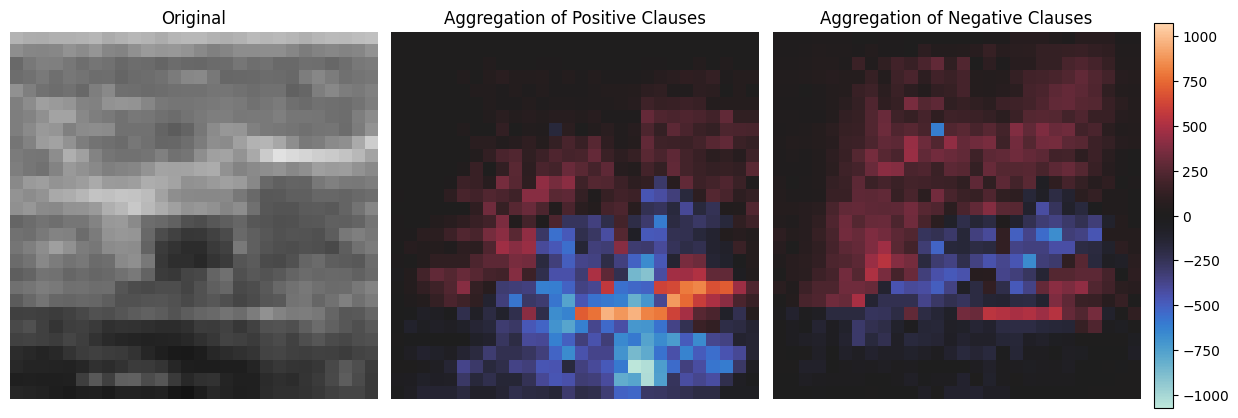

Visualizing sample 123  |  predicted class: 0
2026-04-10 15:22:27,547 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7674099b39b0>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s123_chan.svg


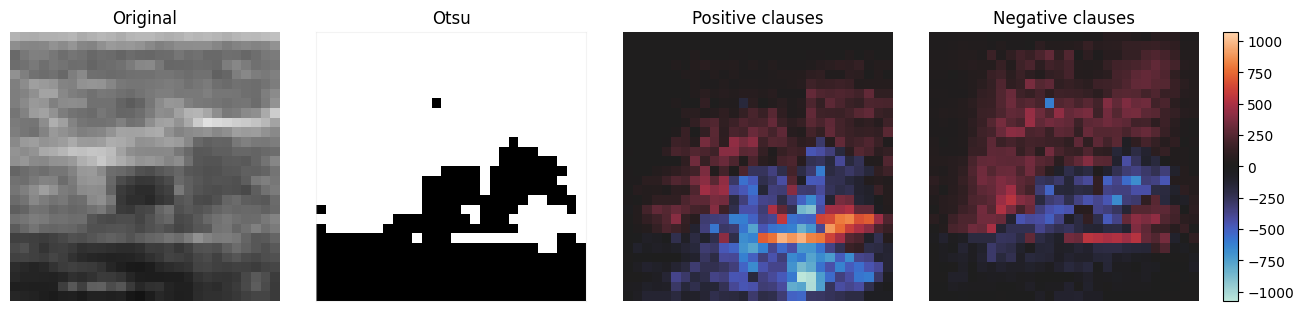

In [10]:
image_index =  123
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 26  |  predicted class: 0
2026-04-10 15:22:30,902 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7674098862d0>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s26_aggr.svg


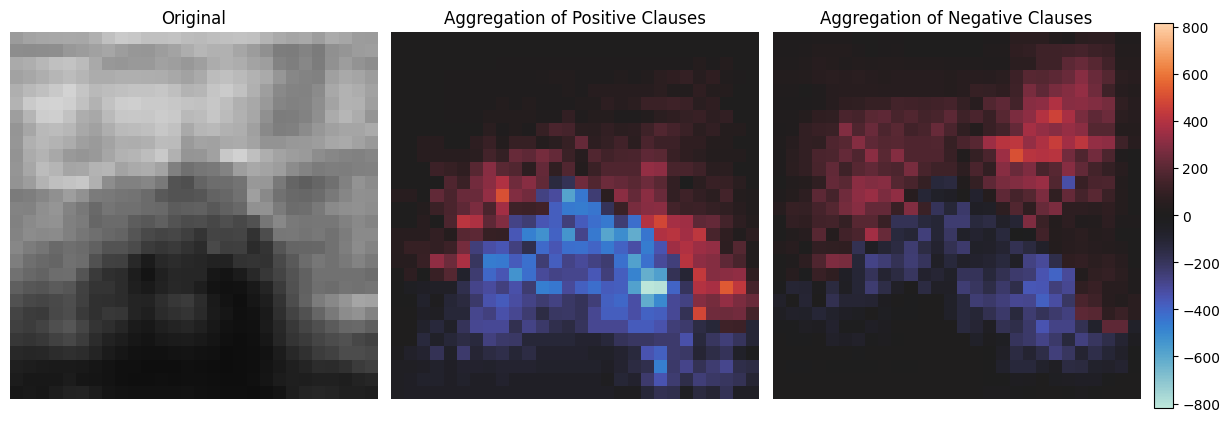

Visualizing sample 26  |  predicted class: 0
2026-04-10 15:22:34,288 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740977d250>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c0_s26_chan.svg


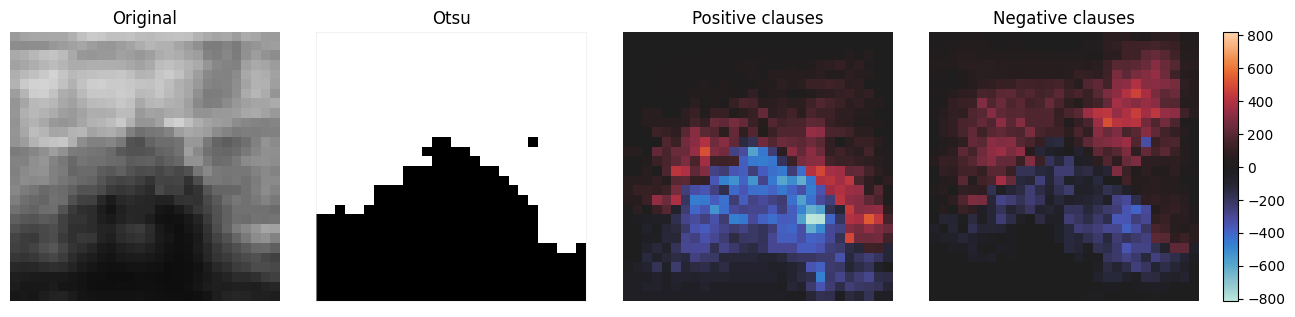

In [11]:
image_index =  26
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples

In [22]:
for i in range(3): 
    print("============================================")
    image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
    print(f"Selected image index: {image_index}")
    print(f"True class: {Y_test[image_index]}")
    print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 18
True class: 1
Predicted class: 1
Selected image index: 84
True class: 1
Predicted class: 1
Selected image index: 70
True class: 1
Predicted class: 1


1


Visualizing sample 18  |  predicted class: 1
2026-04-10 15:22:37,842 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740958a630>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s18_aggr.svg


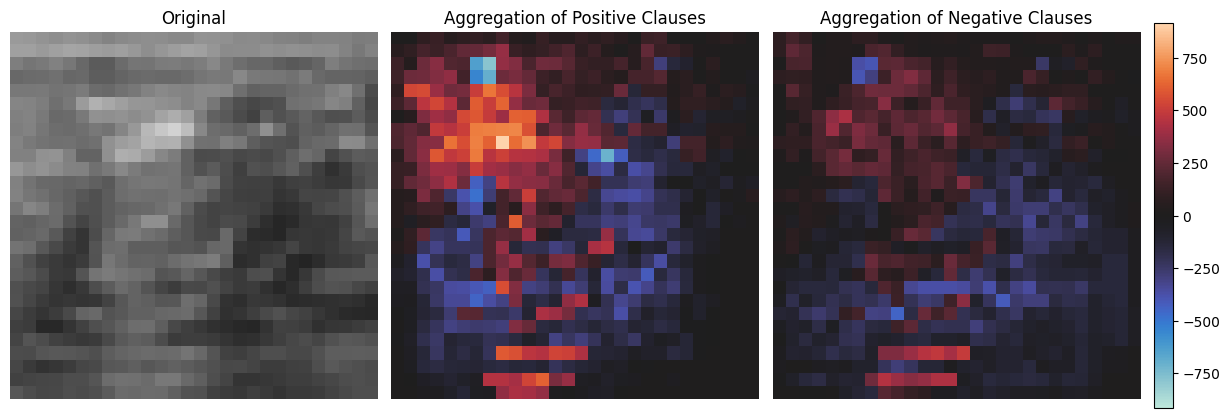

Visualizing sample 18  |  predicted class: 1
2026-04-10 15:22:41,428 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7674094ea5a0>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s18_chan.svg


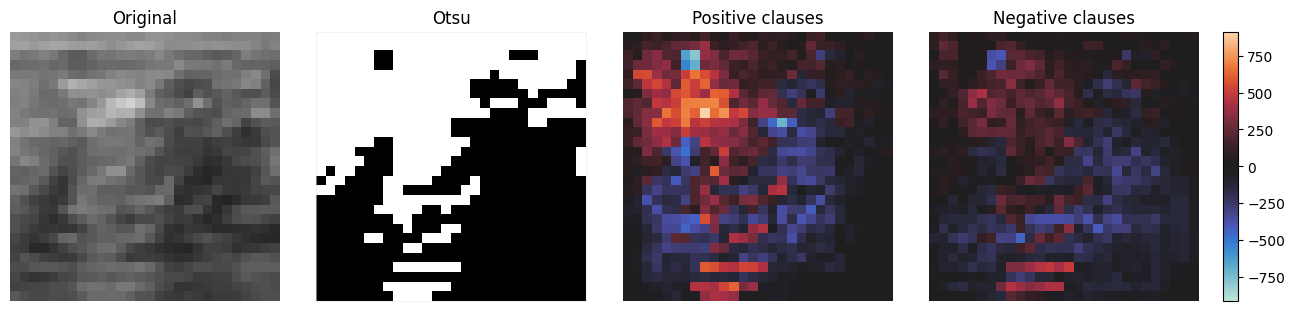

In [12]:
image_index =  18
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1


Visualizing sample 84  |  predicted class: 1
2026-04-10 15:22:46,067 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x767409221670>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s84_aggr.svg


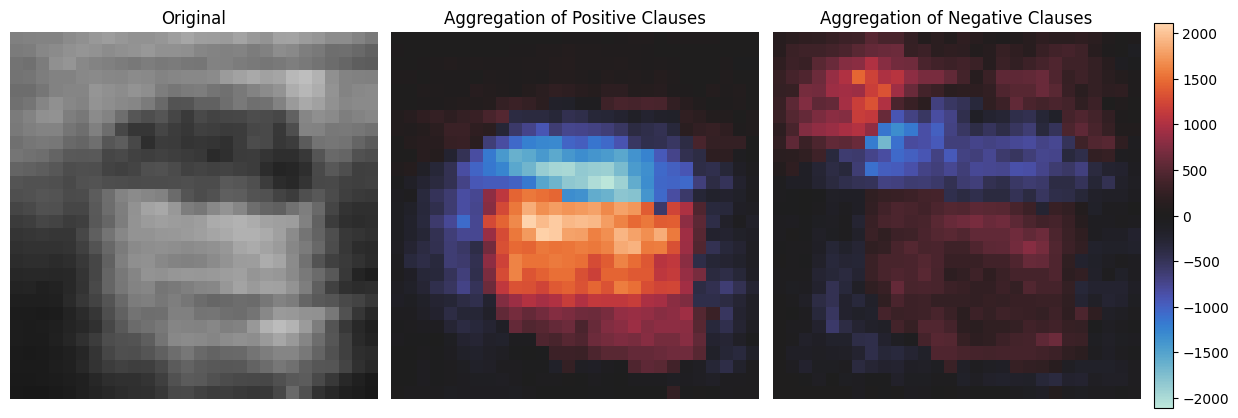

Visualizing sample 84  |  predicted class: 1
2026-04-10 15:22:50,839 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x767409221be0>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s84_chan.svg


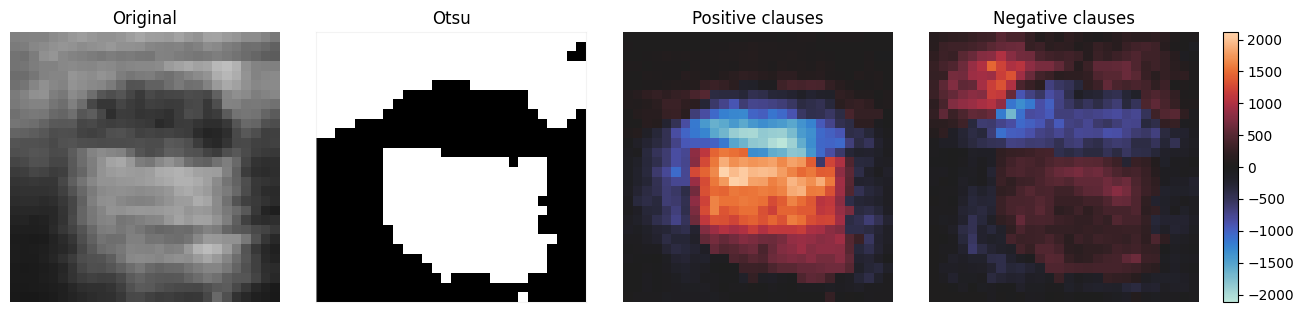

In [13]:
image_index =  84
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 70  |  predicted class: 1
2026-04-10 15:22:55,573 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76740937af00>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s70_aggr.svg


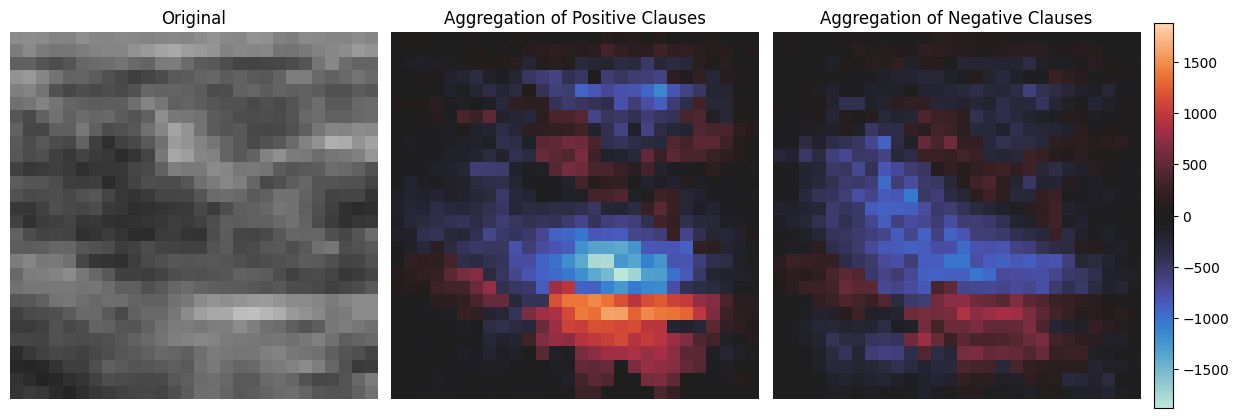

Visualizing sample 70  |  predicted class: 1
2026-04-10 15:23:00,448 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x767409450a40>
Saved to saved_heatmaps/otsu/breast_otsu_lh_c1_s70_chan.svg


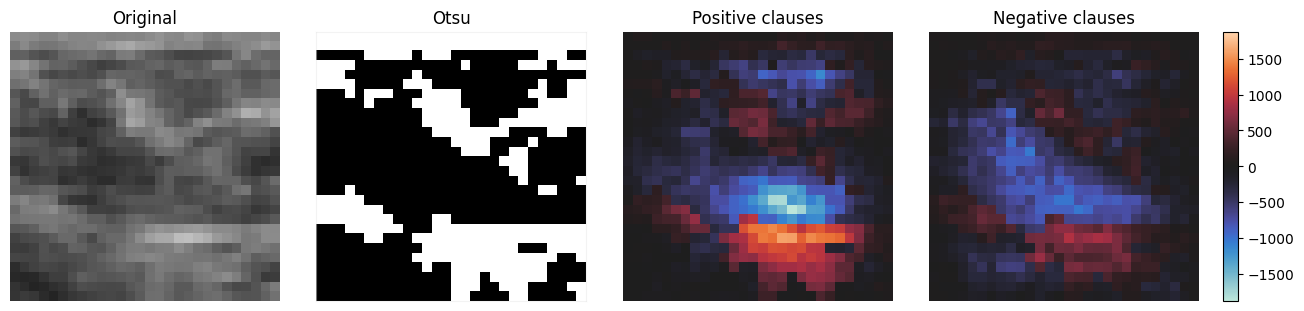

In [14]:
image_index =  70
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap 0

Averaging over 28 correctly predicted samples of class 0
2026-04-06 16:12:11,319 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x705c0c463da0>


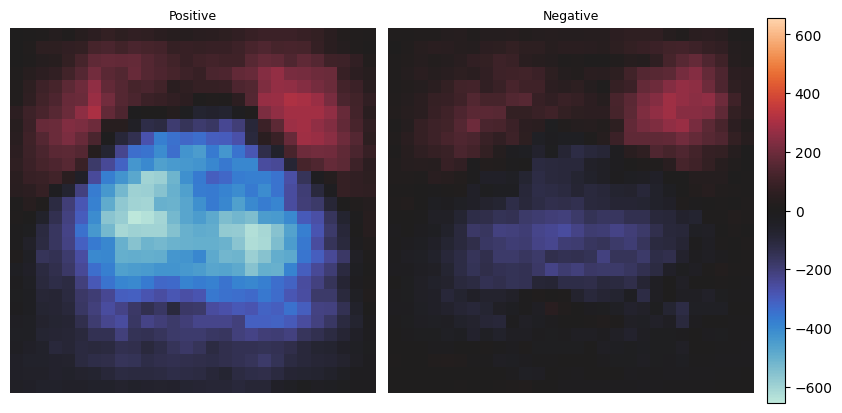

In [16]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 0

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:48:15,366 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:48:15,368 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:48:15,397 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c89f6be5400>
Saved to saved_heatmaps/otsu/breast_otsu_gh_c0.svg


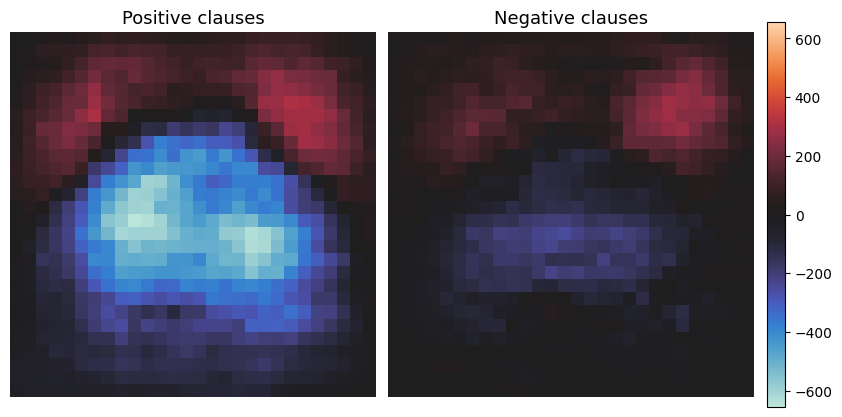

pos shape: (28, 28), min: -656.04, max: 312.46
neg shape: (28, 28), min: -253.11, max: 286.75
saved_heatmaps/otsu/breast_otsu_gh_c0.svg


In [7]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

In [8]:
os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

target_class = 1

global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

NameError: name 'tm' is not defined

2026-04-10 18:48:20,660 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c89ee024890>
Saved to saved_heatmaps/otsu/breast_otsu_gh_c1.svg


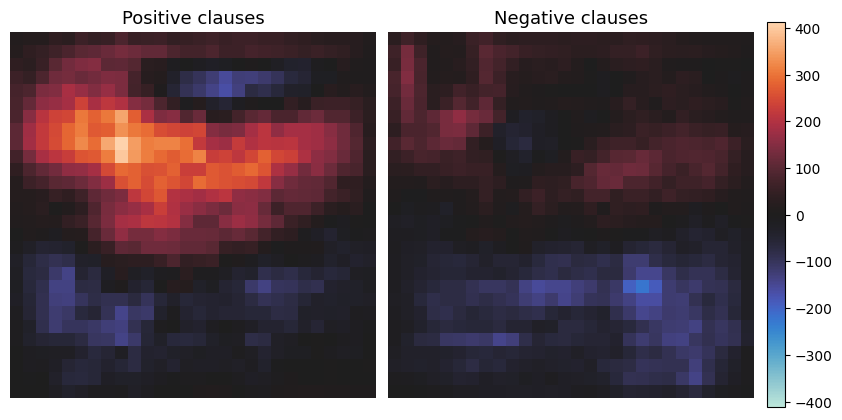

pos shape: (28, 28), min: -167.19, max: 412.27
neg shape: (28, 28), min: -222.52, max: 164.18
saved_heatmaps/otsu/breast_otsu_gh_c1.svg


In [9]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)